# 🧹 数据清洗与预处理

本Notebook用于数据清洗和预处理

In [11]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 导入自定义模块
import sys
sys.path.append('../src')
from data_processing import load_ev_data, preprocess_ev_data, handle_missing_values, save_processed_data, validate_data, detect_outliers_iqr

In [12]:
# 加载原始数据
df = load_ev_data()
print(f"原始数据形状: {df.shape}")

原始数据形状: (135038, 17)


In [13]:
# 数据验证
validation = validate_data(df)
print("数据验证结果:")
for issue in validation:
    print(f"  - {issue}")

数据验证结果:


In [14]:
# 执行数据预处理
df_processed = preprocess_ev_data(df)
print(f"预处理后数据形状: {df_processed.shape}")
print(f"列名: {df_processed.columns.tolist()}")

预处理后数据形状: (135038, 9)
列名: ['model_year', 'make', 'model', 'ev_type', 'electric_range', 'base_msrp', 'state', 'county', 'age']


In [16]:
# 检测价格异常值（使用预处理后的数据）
price_outliers = detect_outliers_iqr(df_processed, 'base_msrp')
print(f"价格异常值数量: {len(price_outliers)}")
print(f"价格异常值范围: {price_outliers['base_msrp'].min()} - {price_outliers['base_msrp'].max()}")

价格异常值数量: 12
价格异常值范围: 184400.0 - 845000.0


In [17]:
# 检测续航异常值（使用预处理后的数据）
range_outliers = detect_outliers_iqr(df_processed, 'electric_range')
print(f"续航异常值数量: {len(range_outliers)}")
print(f"续航异常值范围: {range_outliers['electric_range'].min()} - {range_outliers['electric_range'].max()}")

续航异常值数量: 0
续航异常值范围: nan - nan


In [18]:
# 执行数据清洗
df_clean = handle_missing_values(df_processed)
print(f"清洗后数据形状: {df_clean.shape}")

清洗后数据形状: (135038, 9)


In [19]:
# 检查清洗后的缺失值
print("清洗后的缺失值统计:")
print(df_clean.isnull().sum())

清洗后的缺失值统计:
model_year        0
make              0
model             0
ev_type           0
electric_range    0
base_msrp         0
state             0
county            0
age               0
dtype: int64


In [20]:
# 清洗后的统计描述
df_clean.describe().round(2)

,model_year,electric_range,base_msrp,age
count,135038.00,135038.00,135038.00,135038.00
mean,2019.66,74.59,59829.14,4.34
std,3.00,98.74,3653.82,3.00
min,1997.00,0.00,31950.00,0.00
25%,2018.00,0.00,59900.00,2.00
50%,2021.00,21.00,59900.00,3.00
75%,2022.00,150.00,59900.00,6.00
max,2024.00,337.00,845000.00,27.00


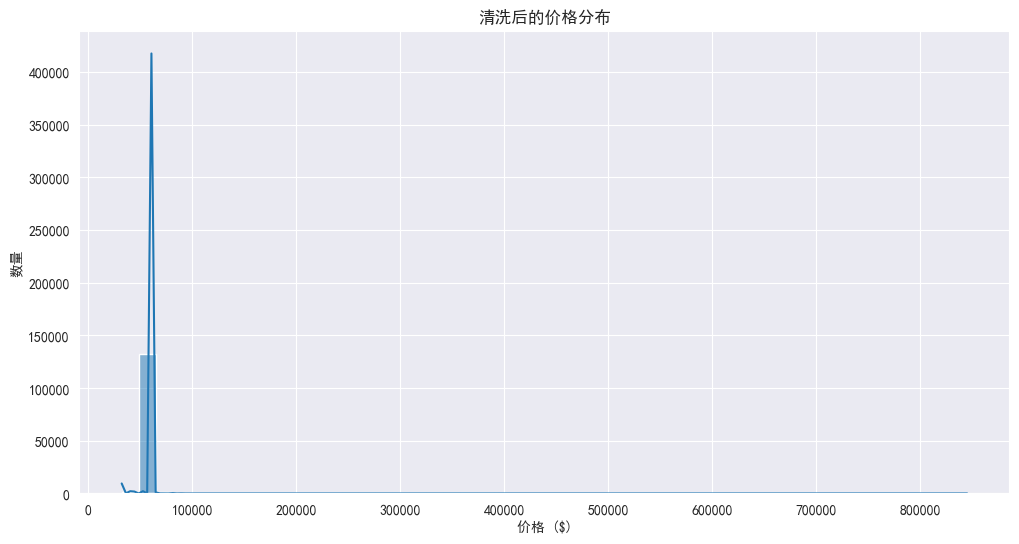

In [21]:
# 可视化：清洗后的价格分布
plt.figure(figsize=(12, 6))
sns.histplot(df_clean['base_msrp'], bins=50, kde=True)
plt.title('清洗后的价格分布')
plt.xlabel('价格 ($)')
plt.ylabel('数量')
plt.show()

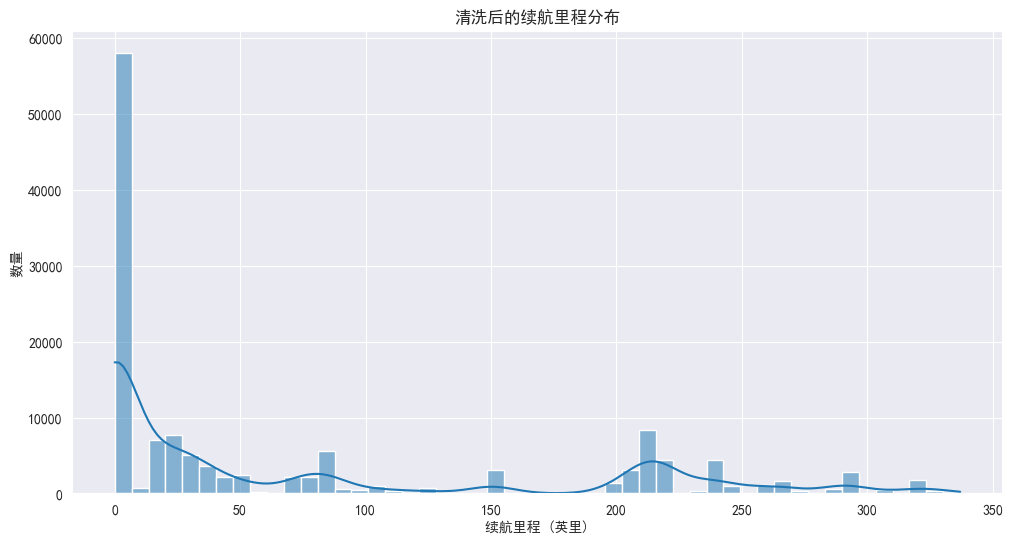

In [22]:
# 可视化：清洗后的续航分布
plt.figure(figsize=(12, 6))
sns.histplot(df_clean['electric_range'], bins=50, kde=True)
plt.title('清洗后的续航里程分布')
plt.xlabel('续航里程 (英里)')
plt.ylabel('数量')
plt.show()

In [23]:
# 保存清洗后的数据
save_processed_data(df_clean, 'cleaned_ev_data.csv')

## 📝 清洗总结

### 数据处理流程

1. **数据加载**: 成功加载原始电动汽车数据集，包含 **135,038** 条记录，17个字段

2. **数据预处理**: 
   - 选择了9个关键字段：model_year, make, model, ev_type, electric_range, base_msrp, state, county, age
   - 将MSRP为0的值标记为缺失值（可能是数据缺失）
   - 计算车龄（age = 2024 - model_year）
   - 数据维度从 (135038, 17) 精简为 (135038, 9)

3. **缺失值处理**: 
   - 使用**中位数**填充数值型变量的缺失值（如 base_msrp, electric_range）
   - 使用 **'Unknown'** 填充分类型变量的缺失值
   - 清洗后所有字段的缺失值数量均为 **0**

4. **异常值检测**（IQR方法）:
   - **价格异常值**: 检测到 **12** 条记录，价格范围 $184,400 - $845,000
   - **续航异常值**: 未检测到异常值（0条）
   - 注：当前仅检测异常值，未移除，可根据后续分析需求决定是否剔除

5. **数据验证**: 
   - 数据质量良好，未发现严重问题
   - 无超过50%缺失值的列
   - 无单一唯一值的列

6. **最终数据质量**:
   - 清洗后数据：**135,038** 条记录，9个字段
   - 平均车龄：**4.34** 年
   - 平均价格：**$59,829**
   - 平均续航：**74.59** 英里
   - 年份范围：1997-2024
   - 所有字段无缺失值，数据完整性 **100%**